In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import polars as pl
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)

from dafm import plots

In [3]:
alt_id_to_label = {
    # Lorenz96Bao2024EnSF
    # ScoreMatchingMarginal
    # 'cbc355m0': 'EnSF',  # sampling_time_step_count=5
    # '1xvp5lig': 'EnSF',  # sampling_time_step_count=10
    # 'pkwvt6gk': 'EnSF',  # sampling_time_step_count=20
    # 'yq1eaqxr': 'EnSF',  # sampling_time_step_count=50
    # 'ucdez2pm': 'EnSF',  # sampling_time_step_count=100
    # 'vocphl8c': 'EnSF',  # sampling_time_step_count=200
    # '0guis8gf': 'EnSF',  # sampling_time_step_count=500
    
    # 'g4xn1kwq': 'EnSF',  # sampling_time_step_count=50 state_dimension=100
    # 'c3r4fb0f': 'EnSF',  # sampling_time_step_count=50 state_dimension=1000
    # 'ojuwr72j': 'EnSF',  # sampling_time_step_count=50 state_dimension=10000
    # '8j26rw3y': 'EnSF',  # sampling_time_step_count=50 state_dimension=100000
    # 'yq1eaqxr': 'EnSF',  # sampling_time_step_count=50 state_dimension=1000000
    # FlowMatchingMarginal
    # 'ekcw5c3k': 'EnFF',  # sampling_time_step_count=5
    # 'eriikp1u': 'EnFF',  # sampling_time_step_count=10
    # '7igtkq4a': 'EnFF',  # sampling_time_step_count=20
    # 'h8l7xw8q': 'EnFF',  # sampling_time_step_count=50
    # 'f233y6lz': 'EnFF',  # sampling_time_step_count=100
    # 'hnlt8l6r': 'EnFF',  # sampling_time_step_count=200
    # 'kjgcbtou': 'EnFF',  # sampling_time_step_count=500
    
    # 'pf8gfi5r': 'EnFF',  # sampling_time_step_count=50 state_dimension=100
    # 'j6zzitkg': 'EnFF',  # sampling_time_step_count=50 state_dimension=1000
    # 'c0zrk5ad': 'EnFF',  # sampling_time_step_count=50 state_dimension=10000
    # 'kgrulpef': 'EnFF',  # sampling_time_step_count=50 state_dimension=100000
    # 'h8l7xw8q': 'EnFF',  # sampling_time_step_count=50 state_dimension=1000000

    # NavierStokesDim64
    # ScoreMatchingMarginal
    # 'gncoj5bt': 'EnSF',  # sampling_time_step_count=5
    # 'if2agep8': 'EnSF',  # sampling_time_step_count=10
    # 'c2f2fz7j': 'EnSF',  # sampling_time_step_count=20
    # 'vpcuhvjp': 'EnSF',  # sampling_time_step_count=50
    # 'f35cpvjm': 'EnSF',  # sampling_time_step_count=100
    # '597z99o5': 'EnSF',  # sampling_time_step_count=200
    # 'uj7177by': 'EnSF',  # sampling_time_step_count=500
    # FlowMatchingMarginal
    # 'ews5u7pv': 'EnFF',  # sampling_time_step_count=5
    # 'cfbwxnup': 'EnFF',  # sampling_time_step_count=10
    # 'eijvq9xb': 'EnFF',  # sampling_time_step_count=20
    # 'fdyt2eb3': 'EnFF',  # sampling_time_step_count=50
    # '8wulqyhl': 'EnFF',  # sampling_time_step_count=100
    # '6mpvp2wh': 'EnFF',  # sampling_time_step_count=200
    # '1g1wnt91': 'EnFF',  # sampling_time_step_count=500
    
    # NavierStokesDim256
    # ScoreMatchingMarginal
    # 'hjbzsbth': 'EnSF',  # sampling_time_step_count=5
    # '08dypqnt': 'EnSF',  # sampling_time_step_count=10
    # 'x85htb7p': 'EnSF',  # sampling_time_step_count=20
    # 'uoc15dkh': 'EnSF',  # sampling_time_step_count=50
    # '0d4ljpxi': 'EnSF',  # sampling_time_step_count=100
    # 'sosmqxwg': 'EnSF',  # sampling_time_step_count=200
    # 'laolo8z4': 'EnSF',  # sampling_time_step_count=500
    # FlowMatchingMarginal
    # 'knwi8dmh': 'EnFF',  # sampling_time_step_count=5
    # '70e3he2q': 'EnFF',  # sampling_time_step_count=10
    # 'in7i7zwn': 'EnFF',  # sampling_time_step_count=20
    # 'jerb4qqb': 'EnFF',  # sampling_time_step_count=50
    # 'qemxjoa5': 'EnFF',  # sampling_time_step_count=100
    # 'a5gmmmf2': 'EnFF',  # sampling_time_step_count=200
    # 'iofguvgt': 'EnFF',  # sampling_time_step_count=500

    # KuramotoSivashinsky
    'la8cajc1': 'EnSF',  # sampling_time_step_count=10 rng_seed=462133975
    'g671jhti': 'EnFF',  # sampling_time_step_count=10 rng_seed=462133975
    'k8usyldj': 'EnFF',  # sampling_time_step_count=20 rng_seed=462133975
    'as4tbkeo': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    'ic8igmlg': 'EnFF',  # sampling_time_step_count=10 rng_seed=2376999025
    'dwrinhfi': 'EnSF',  # sampling_time_step_count=10 rng_seed=2376999025
    '1h275uvu': 'EnFF',  # sampling_time_step_count=20 rng_seed=2376999025
    'glis0of9': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
}
alt_ids = pl.DataFrame(list(alt_id_to_label.items()), schema=['alt_id', 'label'], orient='row')
alt_ids

alt_id,label
str,str
"""la8cajc1""","""EnSF"""
"""g671jhti""","""EnFF"""
"""k8usyldj""","""EnFF"""
"""as4tbkeo""","""EnSF"""
"""ic8igmlg""","""EnFF"""
"""dwrinhfi""","""EnSF"""
"""1h275uvu""","""EnFF"""
"""glis0of9""","""EnSF"""


In [4]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [5]:
duckdb.sql("""
set variable time_step_times_filepaths = (
    select list(format('~/out/dafm/runs/{}/time_step_times.csv', alt_id)) from alt_ids
);
""")

In [20]:
time_step_times = duckdb.sql("""
select csvs.alt_id, label, rng_seed, sampling_time_step_count as "Sampling timesteps", step, time_s as "Time (s)" from (
    select
        split(filename, '/')[-2] as alt_id,
        step,
        time_s
    from read_csv(getvariable(time_step_times_filepaths), filename=true)
) as csvs
join alt_ids on alt_ids.alt_id = csvs.alt_id
join Conf on Conf.alt_id = alt_ids.alt_id
join Dataset on Conf.Dataset = Dataset.id
join (
    select id, sampling_time_step_count
    from ScoreMatchingMarginal
    union
    select id, sampling_time_step_count
    from FlowMatchingMarginal
) as models on Conf.Model = models.id
;
""").pl()
time_step_times

alt_id,label,rng_seed,Sampling timesteps,step,Time (s)
str,str,i64,i64,i64,f64
"""la8cajc1""","""EnSF""",462133975,10,1,0.153572
"""la8cajc1""","""EnSF""",462133975,10,2,0.001292
"""la8cajc1""","""EnSF""",462133975,10,3,0.001195
"""la8cajc1""","""EnSF""",462133975,10,4,0.00117
"""la8cajc1""","""EnSF""",462133975,10,5,0.022282
…,…,…,…,…,…
"""glis0of9""","""EnSF""",2376999025,20,3996,0.000942
"""glis0of9""","""EnSF""",2376999025,20,3997,0.039275
"""glis0of9""","""EnSF""",2376999025,20,3998,0.001056


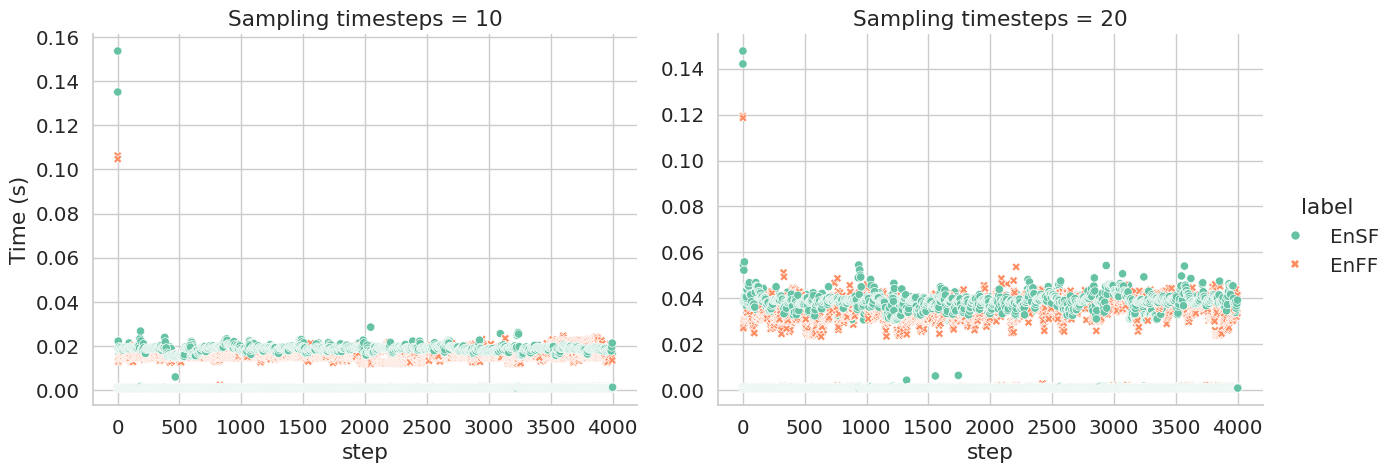

In [21]:
(
    sns.relplot(
        # kind='line',
        data=time_step_times,
        x='step',
        y='Time (s)',
        hue='label',
        style='label',
        col='Sampling timesteps',
        # markers=True,
        # markersize=10,
        aspect=1.3,
        facet_kws=dict(
            sharey=False,
        )
    )
)

shape: (8, 5)
┌──────────┬───────┬────────────┬────────────────────┬───────────┐
│ alt_id   ┆ label ┆ rng_seed   ┆ Sampling timesteps ┆ Time (s)  │
│ ---      ┆ ---   ┆ ---        ┆ ---                ┆ ---       │
│ str      ┆ str   ┆ i64        ┆ i64                ┆ f64       │
╞══════════╪═══════╪════════════╪════════════════════╪═══════════╡
│ ic8igmlg ┆ EnFF  ┆ 2376999025 ┆ 10                 ┆ 19.895476 │
│ g671jhti ┆ EnFF  ┆ 462133975  ┆ 10                 ┆ 18.393692 │
│ 1h275uvu ┆ EnFF  ┆ 2376999025 ┆ 20                 ┆ 39.59936  │
│ k8usyldj ┆ EnFF  ┆ 462133975  ┆ 20                 ┆ 38.96152  │
│ dwrinhfi ┆ EnSF  ┆ 2376999025 ┆ 10                 ┆ 21.96162  │
│ la8cajc1 ┆ EnSF  ┆ 462133975  ┆ 10                 ┆ 21.7673   │
│ as4tbkeo ┆ EnSF  ┆ 462133975  ┆ 20                 ┆ 41.826881 │
│ glis0of9 ┆ EnSF  ┆ 2376999025 ┆ 20                 ┆ 42.31923  │
└──────────┴───────┴────────────┴────────────────────┴───────────┘


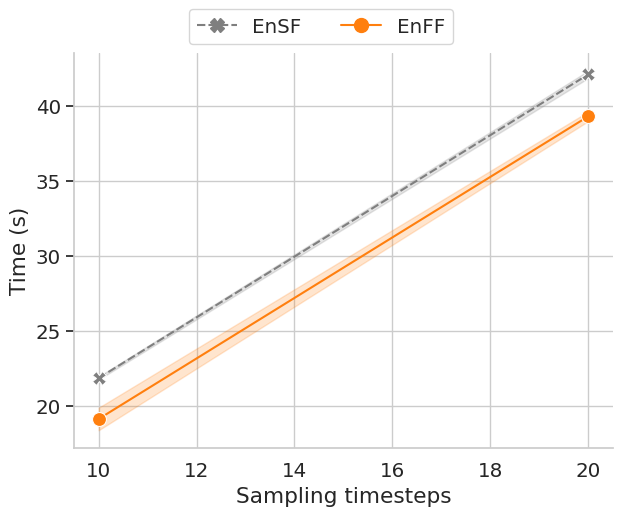

In [23]:
data = (
    time_step_times
    .group_by('alt_id', 'label', 'rng_seed', 'Sampling timesteps')
    .agg(pl.col('Time (s)').sum())
    .sort('label', 'Sampling timesteps')
)
print(data)
plot_times = (
    sns.relplot(
        kind='line',
        data=data,
        x='Sampling timesteps',
        y='Time (s)',
        hue='label',
        hue_order=['EnSF', 'EnFF'],
        style='label',
        palette={
            'EnSF': 'tab:gray',
            'EnFF': 'tab:orange',
        },
        markers=True,
        markersize=10,
        aspect=1.3,
    )
    .set(
        # xscale='log',
        # yscale='log',
    )
)
ax_twin = plot_times.axes[0][0].twinx()
ax_twin.set_axis_off()
sns.move_legend(
    plot_times,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)

In [45]:
table = (
    data
    .group_by('label', 'Sampling timesteps')
    .agg(
        pl.col('Time (s)').mean().alias('Time mean (s)'),
        pl.col('Time (s)').std(ddof=0).alias('Time std. (s)'),
    )
    .select(
        pl.format('{} ({})', pl.col('label'), pl.col('Sampling timesteps')).alias('Model'),
        # (pl.col('label') + ' (' + pl.col('Sampling timesteps').cast(str) + ')').alias('Model'),
        pl.format(
            r'${}_{{\pm {}}}$',
            pl.col('Time mean (s)').map_elements(lambda x: f'{x:.2f}', return_dtype=str),
            pl.col('Time std. (s)').map_elements(lambda x: f'{x:.2f}', return_dtype=str),
        ).alias('Time (s)'),
    )
)
table

Model,Time (s)
str,str
"""EnFF (10)""","""$19.14_{{\pm 0.75}}$"""
"""EnSF (10)""","""$21.86_{{\pm 0.10}}$"""
"""EnSF (20)""","""$42.07_{{\pm 0.25}}$"""
"""EnFF (20)""","""$39.28_{{\pm 0.32}}$"""


In [48]:
print(table.to_pandas().to_latex(index=False))

\begin{tabular}{ll}
\toprule
Model & Time (s) \\
\midrule
EnFF (10) & $19.14_{{\pm 0.75}}$ \\
EnSF (10) & $21.86_{{\pm 0.10}}$ \\
EnSF (20) & $42.07_{{\pm 0.25}}$ \\
EnFF (20) & $39.28_{{\pm 0.32}}$ \\
\bottomrule
\end{tabular}



In [10]:
plots.save_all_subfigures(plot_times, 'ExecutionTimeSum')